In [10]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras import activations
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from numpy import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

**Data Preparation**

In [11]:
N = 28 # number of rows and columns of the input square matrix
C = 10 # number of total classes (e.g. , 10 possible digits )
 # load the data and split it between train and test sets
( x_train , labels_train ) , ( x_test , labels_test ) = keras . datasets . mnist . load_data () # uint8 (0 -255)
print (" Input data type :", x_train . dtype )
print (" Min value :", x_train . min () )
print (" Max value :", x_train . max () )
print (" Shape of the training examples :", x_train . shape )
print (" Shape of the test examples :", x_test . shape )
# scale images to the [0 , 1] range
x_train = x_train / 255
x_test = x_test / 255
print (" Input data type ( after scaling ):", x_train . dtype )
print (" Min value ( after scaling ):", x_train . min () )
print (" Max value ( after scaling ):", x_train . max () )

 # make sure images have shape (28 , 28 , 1)
n_examples_train = x_train . shape [0]
n_examples_test = x_test . shape [0]
x_train = x_train . reshape (( n_examples_train , N , N , 1) )
x_test = x_test . reshape (( n_examples_test , N , N , 1) )

print (" Shape of the training examples ( after reshaping ):", x_train . shape )
print (" Shape of the test examples ( after reshaping ):", x_test . shape )

 # convert labels to one - hot encoded labels using a custom method (to be defined in the exercises 11 and 12)
print (" Shape of the trainin labels :", labels_train . shape )
print (" Shape of the test labels :", labels_test . shape )
y_train =  keras.utils.to_categorical ( labels_train , C )
y_test =  keras.utils.to_categorical ( labels_test , C)
print (" Shape of the trainin labels ( after one - hot encoding ):", y_train . shape )
print (" Shape of the test labels ( after one - hot encoding ):", y_test . shape )


 Input data type : uint8
 Min value : 0
 Max value : 255
 Shape of the training examples : (60000, 28, 28)
 Shape of the test examples : (10000, 28, 28)
 Input data type ( after scaling ): float64
 Min value ( after scaling ): 0.0
 Max value ( after scaling ): 1.0
 Shape of the training examples ( after reshaping ): (60000, 28, 28, 1)
 Shape of the test examples ( after reshaping ): (10000, 28, 28, 1)
 Shape of the trainin labels : (60000,)
 Shape of the test labels : (10000,)
 Shape of the trainin labels ( after one - hot encoding ): (60000, 10)
 Shape of the test labels ( after one - hot encoding ): (10000, 10)


**Neural Network Design**

**Neural Network design and Neural Network Training and plot losses**

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Convolution_Layer_1 (Conv2D)    │ (None, 24, 24, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Average_Pooling_Layer_1         │ (None, 12, 12, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer_1 (Dropout)       │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution_Layer_2 (Conv2D)    │ (None, 8, 8, 32)       │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Average_Pooling_Layer_2         │ (None, 4, 4, 32)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer_2 (Dropout)       │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Layer (Dense)             │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,378 (71.79 KB)

 Trainable params: 18,378 (71.79 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.1476 - loss: 2.2763 - val_accuracy: 0.4075 - val_loss: 2.1341
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.2825 - loss: 2.0346 - val_accuracy: 0.6397 - val_loss: 1.5102
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.3718 - loss: 1.7846 - val_accuracy: 0.6662 - val_loss: 1.2748
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.4437 - loss: 1.6045 - val_accuracy: 0.7397 - val_loss: 1.0438
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.4968 - loss: 1.4737 - val_accuracy: 0.7845 - val_loss: 0.8992
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.5524 - loss: 1.3436 - val_accuracy: 0.8325 - val_loss: 0.7782
Epoch 7/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.5935 - loss: 1.2372 - val_accuracy: 0.8557 - val_loss: 0.6496
Epoch 8/100
211/21

Text(0, 0.5, 'Loss')

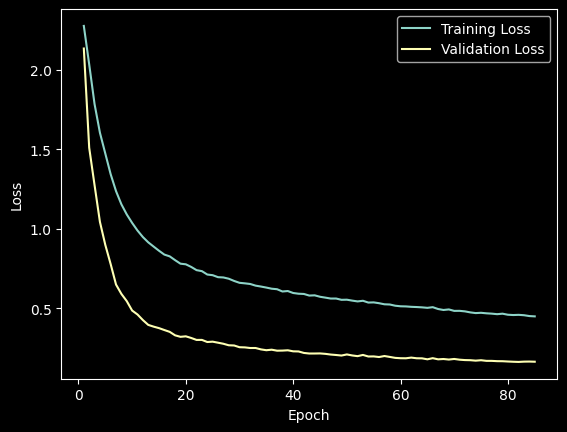

In [12]:
from ast import Name
input_shape = (N , N , 1) # input dimension (grey - scale image 28 x 28 , represented as a single input feature map 28 x28x1 )



 # model design
model = keras.Sequential (
[
 keras.Input ( shape = input_shape ) , # input layer
 #keras.layers.Flatten () , # flatten layer ( from multiple dimensions to a 1 -D)

 keras.layers.Conv2D (16, (5, 5), activation='relu', name="Convolution_Layer_1") ,
 keras.layers.AveragePooling2D ((2,2), (2,2), padding='valid', name = "Average_Pooling_Layer_1" ) ,
 keras.layers.Dropout (0.25, name = "Dropout_Layer_1") ,
 keras.layers.Conv2D (32, (5,5), activation = 'relu', name="Convolution_Layer_2") ,
 keras.layers.AveragePooling2D ((2,2), (2,2), padding='valid', name = "Average_Pooling_Layer_2" ) ,
 keras.layers.Dropout (0.25, name = "Dropout_Layer_2") ,
 keras.layers.Flatten () ,
 keras.layers.Dense (C , activation ='softmax', name = "Dense_Layer") ,

]
)

 # inspect model
model.summary ()


keras.utils.plot_model(
    model,
    to_file="model.png",
    show_shapes=True,
    show_layer_names=True,
    rankdir="UD",
    dpi=50  # Smaller DPI for compact output
)


lr = 0.003 # learning rate
momentum = 0.9 # momentum term
# defining the optimizer ( stochastic gradient descent with momentum )
optimizer = keras.optimizers.SGD ( learning_rate = lr , momentum = momentum ) # SGD with
#momentum

# compiling the model = defining the desired loss function to be minimized , the
#algorithm to use for the optimization process, and other metrics to track
model.compile ( loss ='categorical_crossentropy', optimizer = optimizer , metrics =["accuracy"])

valid_ratio = 0.1 # ratio of the overall training set to held back as validation set
 # extracting the validation set as the first 10% of examples
x_valid = x_train [: round ( valid_ratio * n_examples_train ) ,: ,: ,:]
y_valid = y_train [: round ( valid_ratio * n_examples_train ) ,:]
labels_valid = labels_train [: round ( valid_ratio * n_examples_train )]
 # assigning back the training set as the remaining 90% of examples
x_train = x_train [ round ( valid_ratio * n_examples_train ) : ,: ,: ,:]
y_train = y_train [ round ( valid_ratio * n_examples_train ) : ,:]
labels_train = labels_train [ round ( valid_ratio * n_examples_train ) :]


 # defining the ModelCheckpoint callback
model_checkpoint_callback = keras.callbacks.ModelCheckpoint (
filepath ='best_mdl.keras', # set to ’best_mdl . keras ’ if you want only the best
#model , overall or to ’{ epoch :02 d} -{ val_loss :.5 f}. keras ’ if you want to save the
#best model as the training proceed ( best model over time )
monitor ='val_loss', # set to the metric that you want to track for the early
#stopped model ( evaluated offline )
 save_best_only = True )

early_stopping_callback = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 3, verbose = 1)

model_callbacks = [
    model_checkpoint_callback ,
    early_stopping_callback ,
]

datagen = ImageDataGenerator(
    rotation_range=90,      # Random rotation up to 15 degrees
    width_shift_range=0.1,  # Optional: horizontal shifts
    height_shift_range=0.1, # Optional: vertical shifts
    zoom_range=0.1          # Optional: zoom
)

 # start optimizing the network
batch_size = 256 #128 # mini - batch size
max_epochs = 100# maximum number of epochs

history = model.fit ( datagen.flow(x_train , y_train ,
batch_size = batch_size) ,
epochs = max_epochs ,
validation_data =( x_valid , y_valid ) ,
callbacks =[ model_callbacks ])

 # extracting training and validation losses , training and validation accuracies
train_loss = history.history ['loss']
train_acc = history.history ['accuracy']
valid_loss = history.history ['val_loss']
valid_acc = history.history ['val_accuracy']


xaxis = np.linspace(1, len(history.history['loss']), len(history.history['loss']))
plt.figure()
plt.plot(xaxis, history.history['loss'], label='Training Loss')
plt.plot(xaxis, history.history['val_loss'], label='Validation Loss')
plt.legend(loc='best')
plt.xlabel('Epoch')
plt.ylabel('Loss')
#plt.show()

In [14]:
xaxis = np.linspace(1,max_epochs,max_epochs)
print(xaxis.shape)
print(xaxis)

(100,)
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100.]


**Trained Network evaluation and accuracy computation**

In [15]:
model = keras.models.load_model ('best_mdl.keras')
proba_test = model.predict ( x_test )
proba_valid = model.predict( x_valid )
proba_train = model.predict( x_train )

print(proba_test)
print(proba_test.shape)
which_number_is_it = np.argmax(proba_test, axis=1)
print(which_number_is_it.shape)
print(which_number_is_it);
print('Length of labels_test:',labels_test.shape)
print(type(labels_test))
print(type(which_number_is_it))
#plt.figure()
#plt.plot(labels_test,which_number_is_it,'p')

y_pred_valid = np.argmax(proba_valid, axis=1)
y_pred_train = np.argmax(proba_train, axis=1)

print(labels_test)
print(type(labels_test))
print((which_number_is_it == labels_test).shape)





accuracy_test = np.sum(which_number_is_it == labels_test)*100/len(labels_test)
accuracy_valid = np.sum(y_pred_valid == labels_valid)*100/len(labels_valid)
accuracy_train = np.sum(y_pred_train == labels_train)*100/len(labels_train)
print('Accuracy on test set: ',accuracy_test)
print('Accuracy on validation set: ',accuracy_valid)
print('Accuracy on train set: ',accuracy_train)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
[[5.2467862e-05 2.8051692e-03 7.3671816e-03 ... 9.8718888e-01
  3.8249473e-06 4.2189719e-04]
 [1.0662831e-04 5.3662043e-06 9.9956673e-01 ... 5.8178564e-05
  1.1391697e-05 5.7488751e-07]
 [4.1082785e-05 9.9302703e-01 2.3856830e-04 ... 5.5212057e-03
  3.6572151e-06 1.7893644e-05]
 ...
 [2.7692187e-07 3.4191111e-05 5.3210667e-04 ... 1.8170007e-03
  1.5755519e-03 6.0355739e-04]
 [4.0836418e-05 1.0317641e-05 1.4589332e-05 ... 4.2558022e-05
  3.5149835e-03 6.2792026e-03]
 [4.6086105e-05 1.9296652e-07 1.7024966e-05 ... 1.1331699e-07
  6.0424290e-04 5.8767591e-07]]
(10000, 10)
(10000,)
[7 2 1 ... 4 5 6]
Length of labels_test: (10000,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[7 2 1 ... 4 5 6]
<class 'numpy.ndarray'>
(10000,)
Accuracy on test set:  95.35
Accuracy on validation set:  95.23333333333333
Accuracy on train set:  95.00925925925925


**Confusion matrices plot**

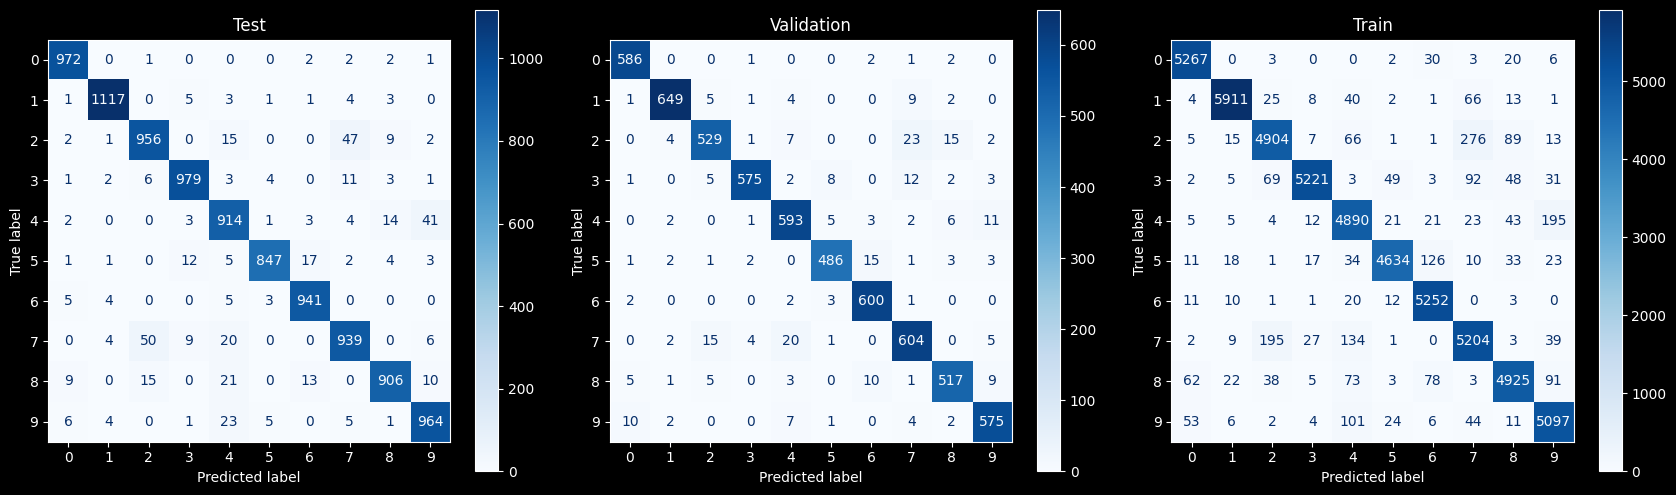

In [16]:
cm_test = confusion_matrix(labels_test, which_number_is_it)
cm_valid = confusion_matrix(labels_valid, y_pred_valid)
cm_train = confusion_matrix(labels_train, y_pred_train)
#print(cm_test)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=np.arange(10))
disp.plot(cmap='Blues', values_format='d',ax = axes[0])  # 'd' = integer counts [web:3][web:7]
axes[0].set_title('Test')


disp = ConfusionMatrixDisplay(confusion_matrix=cm_valid, display_labels=np.arange(10))
disp.plot(cmap='Blues', values_format='d',ax=axes[1])  # 'd' = integer counts [web:3][web:7]
axes[1].set_title('Validation')


disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=np.arange(10))
disp.plot(cmap='Blues', values_format='d',ax=axes[2])  # 'd' = integer counts [web:3][web:7]
axes[2].set_title('Train')

plt.tight_layout()
plt.show()



**Layer analysis**

In [17]:
model = keras.models.load_model('best_mdl.keras')

**Model testing on a random image**

(1, 28, 28)


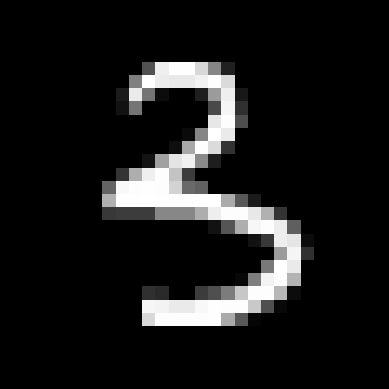

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
[[2.5957556e-07 6.4632331e-08 1.0656341e-03 9.9789751e-01 2.9937137e-04
  3.1111031e-04 1.6172754e-07 1.5881234e-04 1.7409268e-04 9.2883340e-05]]
3
The CNN correctly recognized the number! It is a:  3


In [18]:
idx = random.randint(0, 10000-1)

trial = x_test[idx:idx+1, :, :, :]   # shape (1, 28, 28, 1)

# Option 2: start from (28, 28, 1) and add axis

img = x_test[idx, :, :, 0]      # (28, 28)
trial = np.expand_dims(img, axis=0)  # shape (1, 28, 28, 1)

print(trial.shape)

plt.figure()
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()


y_prob_trial = model.predict(trial);
print(y_prob_trial)
y_pred_trial = np.argmax(y_prob_trial)
print(y_pred_trial)
if y_pred_trial == labels_test[idx]:
  print("The CNN correctly recognized the number! It is a: ", y_pred_trial)
else:
  print("Nope, it is not a", y_pred_trial, "! It is a", labels_test[idx])


In [19]:
import numpy as np
from PIL import Image


def rgb2gray(rgb):
    ''' Function that returns a gray-scale image from an input RGB image

     Arguments
     ---------
     rgb: ndarray
           Numpy array containing the RGB image (3-D).
    '''

    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return gray


def load_my_digit(fpath):
    ''' Load and pre-process a handwritten digit contained in a
     picture. The digit is returned as a 28x28 uint8 ndarray.

     Arguments
     ---------
     fpath: string
           Filepath of the target image.

     Author
     ------
     Davide Borra, 2022
    '''
    my_digit = Image.open(fpath)
    my_digit = np.array(my_digit)
    my_digit = rgb2gray(my_digit)

    my_digit = 255-my_digit # inverting dynamic (higher values: foreground, low values: background)
    my_digit[my_digit<128]=0 # roughly bringing to 0 all background

    my_digit = np.array(Image.fromarray(my_digit).resize((28,28)))
    my_digit[my_digit<0] = 0 # saturating to 0 and 255 interpolated values exceeding 0-255 range
    my_digit[my_digit>255] = 255
    return my_digit.astype(np.uint8)

In [20]:
trial_mydigits = load_my_digit('/content/numberthreelessflipped.jpeg')
trial_mydigits = trial_mydigits / 255
label_mydigit = 3
print(trial_mydigits.shape)

img = trial_mydigits
trial_mydigits = np.reshape(trial_mydigits, (1, 28, 28))


print(trial_mydigits.shape)

plt.figure()
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()


y_prob_trial = model.predict(trial_mydigits);
print(y_prob_trial)
y_pred_trial = np.argmax(y_prob_trial)
print(y_pred_trial)
if y_pred_trial == label_mydigit:
  print("The CNN correctly recognized the number! It is a: ", y_pred_trial)
else:
  print("Nope, it is not a", y_pred_trial, "! It is a", label_mydigit)

FileNotFoundError: [Errno 2] No such file or directory: '/content/numberthreelessflipped.jpeg'